# MGSC 416 — Semester Project

## Optimising cafe operations through demand forecasting and inventory planning

**Dataset:** Kaggle cafe transaction data (9,741 transactions, Jan–Dec 2023)  
**Tools:** pandas, numpy, matplotlib, seaborn, statsmodels, gurobipy

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100

---

# Section 1 — Data loading and cleaning (Person 1)

Load both CSVs, inspect the raw data, then clean:
1. Drop rows with invalid item names ("unknown", "error")
2. Fix Total Spent mismatches where Quantity × Price Per Unit ≠ Total Spent
3. Document price inconsistencies per item

### 1.1 Load raw data

In [2]:
raw = pd.read_csv('Cleaned_DataSet.csv', parse_dates=['Transaction Date'])
holidays = pd.read_csv('holidays.csv', parse_dates=['date'])

print(f'Raw transactions: {len(raw):,} rows, {raw.shape[1]} columns')
print(f'Holidays:         {len(holidays):,} rows')
raw.head(10)

Raw transactions: 9,741 rows, 6 columns
Holidays:         205 rows


,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Transaction Date
0,TXN_1961373,coffee,2.0,2.0,4.0,2023-09-08
1,TXN_4977031,cake,4.0,3.0,12.0,2023-05-16
2,TXN_4271903,cookie,4.0,1.0,8.0,2023-07-19
3,TXN_7034554,salad,2.0,5.0,10.0,2023-04-27
4,TXN_3160411,coffee,2.0,2.0,4.0,2023-06-11
5,TXN_2602893,smoothie,5.0,4.0,20.0,2023-03-31
6,TXN_4433211,unknown,3.0,3.0,9.0,2023-10-06
7,TXN_6699534,sandwich,4.0,4.0,16.0,2023-10-28
8,TXN_4717867,juice,5.0,3.0,15.0,2023-07-28
9,TXN_2064365,sandwich,5.0,4.0,20.0,2023-12-31


In [3]:
raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9741 entries, 0 to 9740
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    9741 non-null   object        
 1   Item              9741 non-null   object        
 2   Quantity          9741 non-null   float64       
 3   Price Per Unit    9741 non-null   float64       
 4   Total Spent       9741 non-null   float64       
 5   Transaction Date  9741 non-null   datetime64[ns]
dtypes: datetime64[ns](1), float64(3), object(2)
memory usage: 456.7+ KB


In [4]:
raw.describe()

,Quantity,Price Per Unit,Total Spent,Transaction Date
count,9741.000000,9741.000000,9741.000000,9741
mean,2.977312,2.901499,8.449287,2023-06-25 04:12:29.491838720
min,1.000000,1.000000,1.000000,2023-01-01 00:00:00
25%,2.000000,2.000000,4.000000,2023-03-19 00:00:00
50%,3.000000,3.000000,8.000000,2023-06-23 00:00:00
75%,4.000000,4.000000,12.000000,2023-09-27 00:00:00
max,5.000000,5.000000,20.000000,2023-12-31 00:00:00
std,1.366510,1.217124,5.307016,NaN


### 1.2 Inspect item distribution and identify invalid items

In [5]:
print('Item value counts (raw):')
print(raw['Item'].value_counts())
print(f"\nRows with 'unknown': {(raw['Item'] == 'unknown').sum()}")
print(f"Rows with 'error':   {(raw['Item'] == 'error').sum()}")
print(f'Total invalid:       {((raw["Item"] == "unknown") | (raw["Item"] == "error")).sum()}')

Item value counts (raw):
Item
juice       1499
coffee      1165
cake        1139
sandwich    1131
smoothie    1096
cookie      1092
tea         1089
salad        910
unknown      337
error        283
Name: count, dtype: int64

Rows with 'unknown': 337
Rows with 'error':   283
Total invalid:       620


### 1.3 Drop invalid items

Rows labelled "unknown" and "error" have wildly inconsistent prices and represent corrupted data. We drop all 620 of them.

In [6]:
valid_items = ['coffee', 'tea', 'juice', 'smoothie', 'cake', 'cookie', 'sandwich', 'salad']
df = raw[raw['Item'].isin(valid_items)].copy()
print(f'Rows after dropping invalid items: {len(df):,} (removed {len(raw) - len(df):,})')

Rows after dropping invalid items: 9,121 (removed 620)


### 1.4 Fix Total Spent mismatches

Check how many rows have `Total Spent ≠ Quantity × Price Per Unit` and recalculate.

In [7]:
expected_total = df['Quantity'] * df['Price Per Unit']
mismatch_mask = ~np.isclose(df['Total Spent'], expected_total)
print(f'Mismatched rows: {mismatch_mask.sum():,} out of {len(df):,} ({mismatch_mask.mean():.1%})')

print('\nExamples of mismatched rows:')
df.loc[mismatch_mask].head(10)

Mismatched rows: 1,083 out of 9,121 (11.9%)

Examples of mismatched rows:


,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Transaction Date
2,TXN_4271903,cookie,4.0,1.0,8.0,2023-07-19
19,TXN_3522028,smoothie,3.0,4.0,20.0,2023-04-04
24,TXN_7958992,smoothie,3.0,4.0,8.0,2023-12-13
41,TXN_6650263,tea,2.0,1.5,8.0,2023-01-10
52,TXN_5522862,cookie,3.0,1.0,2.0,2023-03-19
54,TXN_2080895,cake,3.0,3.0,3.0,2023-04-19
62,TXN_4987129,sandwich,3.0,3.0,8.0,2023-10-20
63,TXN_8501819,juice,3.0,3.0,6.0,2023-03-30
65,TXN_8427104,salad,2.0,3.0,10.0,2023-10-27
82,TXN_8035512,tea,3.0,3.0,4.5,2023-10-29


In [8]:
df['Total Spent'] = df['Quantity'] * df['Price Per Unit']
print('Total Spent recalculated as Quantity × Price Per Unit.')
print(f'Remaining mismatches: {(~np.isclose(df["Total Spent"], df["Quantity"] * df["Price Per Unit"])).sum()}')

Total Spent recalculated as Quantity × Price Per Unit.
Remaining mismatches: 0


### 1.5 Investigate price inconsistencies

Some items have multiple price points. This could indicate different sizes or price changes.

In [9]:
price_summary = (
    df.groupby('Item')['Price Per Unit']
    .agg(['nunique', 'min', 'max', lambda x: sorted(x.unique().tolist())])
)
price_summary.columns = ['n_prices', 'min_price', 'max_price', 'price_values']
price_summary = price_summary.sort_values('n_prices', ascending=False)
print('Price variants per item:')
price_summary

Price variants per item:


,n_prices,min_price,max_price,price_values
Item,,,,
juice,6,1.0,5.0,"[1.0, 1.5, 2.0, 3.0, 4.0, 5.0]"
coffee,2,2.0,3.0,"[2.0, 3.0]"
cookie,2,1.0,3.0,"[1.0, 3.0]"
salad,2,3.0,5.0,"[3.0, 5.0]"
sandwich,2,3.0,4.0,"[3.0, 4.0]"
smoothie,2,3.0,4.0,"[3.0, 4.0]"
tea,2,1.5,3.0,"[1.5, 3.0]"
cake,1,3.0,3.0,[3.0]


In [10]:
for item in df['Item'].unique():
    item_prices = df[df['Item'] == item]['Price Per Unit'].value_counts().sort_index()
    if len(item_prices) > 1:
        print(f'\n{item}:')
        for price, count in item_prices.items():
            print(f'  ${price:.2f} — {count:,} transactions')


coffee:
  $2.00 — 1,108 transactions
  $3.00 — 57 transactions

cookie:
  $1.00 — 1,026 transactions
  $3.00 — 66 transactions

salad:
  $3.00 — 51 transactions
  $5.00 — 859 transactions

smoothie:
  $3.00 — 60 transactions
  $4.00 — 1,036 transactions

sandwich:
  $3.00 — 49 transactions
  $4.00 — 1,082 transactions

juice:
  $1.00 — 38 transactions
  $1.50 — 33 transactions
  $2.00 — 39 transactions
  $3.00 — 1,274 transactions
  $4.00 — 82 transactions
  $5.00 — 33 transactions

tea:
  $1.50 — 1,023 transactions
  $3.00 — 66 transactions


**Observation:** Items with two price points likely represent size variants (e.g. small vs large coffee). We keep both variants and note this as a feature that could be explored further.

### 1.6 Cleaned dataset summary

In [11]:
print(f'Cleaned dataset: {len(df):,} rows, {df.shape[1]} columns')
print(f'Date range: {df["Transaction Date"].min().date()} to {df["Transaction Date"].max().date()}')
print(f'Valid items: {sorted(df["Item"].unique().tolist())}')
print(f'\nColumn types:')
print(df.dtypes)
df.head()

Cleaned dataset: 9,121 rows, 6 columns
Date range: 2023-01-01 to 2023-12-31
Valid items: ['cake', 'coffee', 'cookie', 'juice', 'salad', 'sandwich', 'smoothie', 'tea']

Column types:
Transaction ID              object
Item                        object
Quantity                   float64
Price Per Unit             float64
Total Spent                float64
Transaction Date    datetime64[ns]
dtype: object


,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Transaction Date
0,TXN_1961373,coffee,2.0,2.0,4.0,2023-09-08
1,TXN_4977031,cake,4.0,3.0,12.0,2023-05-16
2,TXN_4271903,cookie,4.0,1.0,4.0,2023-07-19
3,TXN_7034554,salad,2.0,5.0,10.0,2023-04-27
4,TXN_3160411,coffee,2.0,2.0,4.0,2023-06-11


---

# Section 2 — Feature engineering (Person 2)

Derive all analytical features from the transaction dates and the holidays calendar. No external data sources used.

**Features created:**
- Temporal: day_of_week, day_name, is_weekend, month, season, week_number, is_month_start, is_month_end
- Holiday: is_holiday, days_to_next_holiday
- Item: item_category (drinks/food), is_hot_drink

### 2.1 Temporal features

In [12]:
df['day_of_week'] = df['Transaction Date'].dt.dayofweek
df['day_name'] = df['Transaction Date'].dt.day_name()
df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)
df['month'] = df['Transaction Date'].dt.month
df['week_number'] = df['Transaction Date'].dt.isocalendar().week.astype(int)
df['is_month_start'] = df['Transaction Date'].dt.is_month_start.astype(int)
df['is_month_end'] = df['Transaction Date'].dt.is_month_end.astype(int)

season_map = {
    12: 'Winter', 1: 'Winter', 2: 'Winter',
    3: 'Spring', 4: 'Spring', 5: 'Spring',
    6: 'Summer', 7: 'Summer', 8: 'Summer',
    9: 'Autumn', 10: 'Autumn', 11: 'Autumn',
}
df['season'] = df['month'].map(season_map)

print('Temporal features added.')
df[['Transaction Date', 'day_of_week', 'day_name', 'is_weekend', 'month', 'season', 'week_number']].head(10)

Temporal features added.


,Transaction Date,day_of_week,day_name,is_weekend,month,season,week_number
0,2023-09-08,4,Friday,0,9,Autumn,36
1,2023-05-16,1,Tuesday,0,5,Spring,20
2,2023-07-19,2,Wednesday,0,7,Summer,29
3,2023-04-27,3,Thursday,0,4,Spring,17
4,2023-06-11,6,Sunday,1,6,Summer,23
5,2023-03-31,4,Friday,0,3,Spring,13
7,2023-10-28,5,Saturday,1,10,Autumn,43
8,2023-07-28,4,Friday,0,7,Summer,30
9,2023-12-31,6,Sunday,1,12,Winter,52
10,2023-02-06,0,Monday,0,2,Winter,6


### 2.2 Holiday features

Merge the Canadian holidays calendar. Create a binary `is_holiday` flag and compute `days_to_next_holiday`.

In [13]:
holidays_2023 = holidays[holidays['date'].dt.year == 2023].copy()
print(f'Holidays in 2023: {len(holidays_2023)}')
holidays_2023

Holidays in 2023: 13


,date,holiday
156,2023-01-02,New Year's Day
157,2023-02-20,Family Day
158,2023-04-07,Good Friday
159,2023-05-22,Victoria Day
160,2023-07-03,Canada Day
161,2023-08-07,Civic Holiday
162,2023-09-04,Labour Day
163,2023-10-09,Thanksgiving
164,2023-12-25,Christmas Day
165,2023-12-26,Boxing Day


In [14]:
holiday_dates = set(holidays_2023['date'].dt.date)
df['is_holiday'] = df['Transaction Date'].dt.date.isin(holiday_dates).astype(int)

holiday_dates_sorted = sorted(holidays_2023['date'].tolist())

def days_to_next_holiday(date, holiday_list):
    future = [h for h in holiday_list if h >= date]
    if not future:
        return np.nan
    return (future[0] - date).days

df['days_to_next_holiday'] = df['Transaction Date'].apply(
    lambda d: days_to_next_holiday(d, holiday_dates_sorted)
)

print(f'Transactions on holidays: {df["is_holiday"].sum():,}')
print(f'days_to_next_holiday range: {df["days_to_next_holiday"].min():.0f} – {df["days_to_next_holiday"].max():.0f}')
df[['Transaction Date', 'is_holiday', 'days_to_next_holiday']].head(10)

Transactions on holidays: 289
days_to_next_holiday range: 0 – 76


,Transaction Date,is_holiday,days_to_next_holiday
0,2023-09-08,0,31.0
1,2023-05-16,0,6.0
2,2023-07-19,0,19.0
3,2023-04-27,0,25.0
4,2023-06-11,0,22.0
5,2023-03-31,0,7.0
7,2023-10-28,0,58.0
8,2023-07-28,0,10.0
9,2023-12-31,0,NaN
10,2023-02-06,0,14.0


### 2.3 Item-derived features

In [15]:
drinks = {'coffee', 'tea', 'juice', 'smoothie'}
hot_drinks = {'coffee', 'tea'}

df['item_category'] = df['Item'].apply(lambda x: 'drinks' if x in drinks else 'food')
df['is_hot_drink'] = df['Item'].apply(lambda x: 1 if x in hot_drinks else 0)

print('Item category distribution:')
print(df['item_category'].value_counts())
print(f'\nHot drink transactions: {df["is_hot_drink"].sum():,}')

Item category distribution:
item_category
drinks    4849
food      4272
Name: count, dtype: int64

Hot drink transactions: 2,254


### 2.4 Final enriched dataset

In [16]:
print(f'Enriched dataset: {len(df):,} rows, {df.shape[1]} columns')
print(f'\nColumns: {list(df.columns)}')
df.head()

Enriched dataset: 9,121 rows, 18 columns

Columns: ['Transaction ID', 'Item', 'Quantity', 'Price Per Unit', 'Total Spent', 'Transaction Date', 'day_of_week', 'day_name', 'is_weekend', 'month', 'week_number', 'is_month_start', 'is_month_end', 'season', 'is_holiday', 'days_to_next_holiday', 'item_category', 'is_hot_drink']


,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Transaction Date,day_of_week,day_name,is_weekend,month,week_number,is_month_start,is_month_end,season,is_holiday,days_to_next_holiday,item_category,is_hot_drink
0,TXN_1961373,coffee,2.0,2.0,4.0,2023-09-08,4,Friday,0,9,36,0,0,Autumn,0,31.0,drinks,1
1,TXN_4977031,cake,4.0,3.0,12.0,2023-05-16,1,Tuesday,0,5,20,0,0,Spring,0,6.0,food,0
2,TXN_4271903,cookie,4.0,1.0,4.0,2023-07-19,2,Wednesday,0,7,29,0,0,Summer,0,19.0,food,0
3,TXN_7034554,salad,2.0,5.0,10.0,2023-04-27,3,Thursday,0,4,17,0,0,Spring,0,25.0,food,0
4,TXN_3160411,coffee,2.0,2.0,4.0,2023-06-11,6,Sunday,1,6,23,0,0,Summer,0,22.0,drinks,1


In [17]:
df.to_csv('enriched_dataset.csv', index=False)
print('Saved enriched_dataset.csv')

Saved enriched_dataset.csv


---

# Section 3 — Descriptive analysis and visualisations (Person 1)

Explore the cleaned and enriched dataset to surface patterns that will guide the prediction and optimisation stages.

### 3.1 Summary statistics

In [18]:
print('=== Summary statistics by item ===')
item_stats = (
    df.groupby('Item')
    .agg(
        transactions=('Transaction ID', 'count'),
        avg_quantity=('Quantity', 'mean'),
        avg_price=('Price Per Unit', 'mean'),
        total_revenue=('Total Spent', 'sum'),
        avg_revenue_per_txn=('Total Spent', 'mean'),
    )
    .round(2)
    .sort_values('total_revenue', ascending=False)
)
item_stats

=== Summary statistics by item ===


,transactions,avg_quantity,avg_price,total_revenue,avg_revenue_per_txn
Item,,,,,
sandwich,1131,3.03,3.96,13538.0,11.97
juice,1499,3.01,2.99,13465.5,8.98
smoothie,1096,3.06,3.95,13218.0,12.06
salad,910,2.53,4.89,11279.0,12.39
cake,1139,3.04,3.00,10401.0,9.13
coffee,1165,3.05,2.05,7261.0,6.23
tea,1089,3.05,1.59,5296.5,4.86
cookie,1092,2.98,1.12,3651.0,3.34


In [19]:
print('=== Summary statistics by day of week ===')
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_stats = (
    df.groupby('day_name')
    .agg(
        transactions=('Transaction ID', 'count'),
        total_revenue=('Total Spent', 'sum'),
        avg_revenue_per_txn=('Total Spent', 'mean'),
    )
    .round(2)
    .reindex(day_order)
)
day_stats

=== Summary statistics by day of week ===


,transactions,total_revenue,avg_revenue_per_txn
day_name,,,
Monday,1683,14339.5,8.52
Tuesday,1190,10463.0,8.79
Wednesday,1213,10240.5,8.44
Thursday,1255,10847.0,8.64
Friday,1274,10838.5,8.51
Saturday,1228,10430.0,8.49
Sunday,1278,10951.5,8.57


In [20]:
print('=== Summary statistics by season ===')
season_order = ['Winter', 'Spring', 'Summer', 'Autumn']
season_stats = (
    df.groupby('season')
    .agg(
        transactions=('Transaction ID', 'count'),
        total_revenue=('Total Spent', 'sum'),
        avg_revenue_per_txn=('Total Spent', 'mean'),
    )
    .round(2)
    .reindex(season_order)
)
season_stats

=== Summary statistics by season ===


,transactions,total_revenue,avg_revenue_per_txn
season,,,
Winter,2557,22263.0,8.71
Spring,2165,18683.5,8.63
Summer,2193,18493.0,8.43
Autumn,2206,18670.5,8.46


### 3.2 Revenue by item

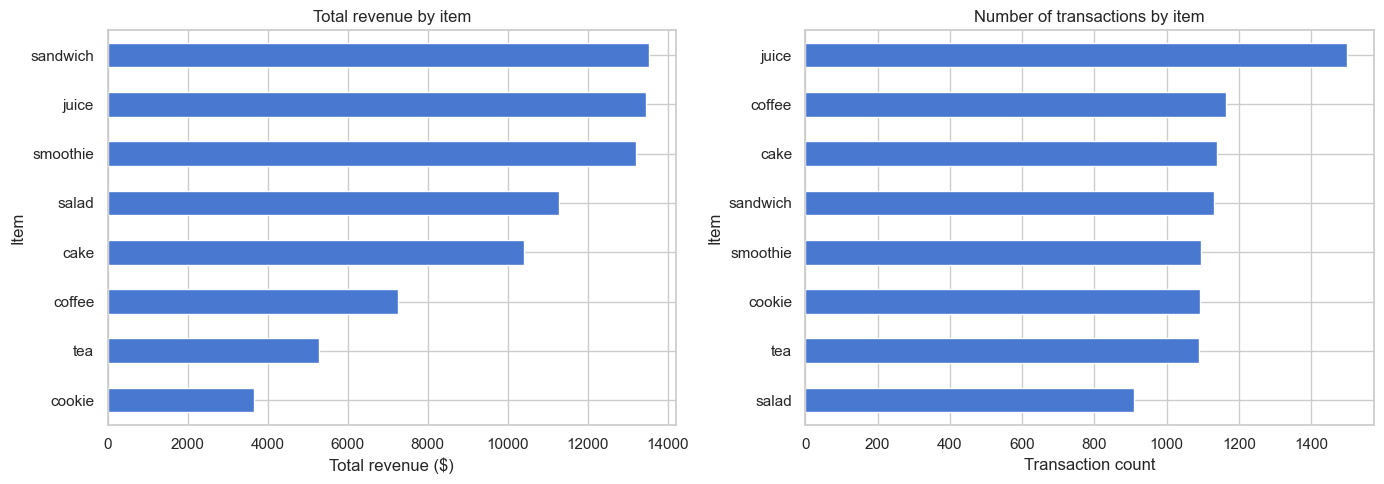

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

item_revenue = df.groupby('Item')['Total Spent'].sum().sort_values(ascending=True)
item_revenue.plot(kind='barh', ax=axes[0])
axes[0].set_title('Total revenue by item')
axes[0].set_xlabel('Total revenue ($)')

item_counts = df['Item'].value_counts().sort_values(ascending=True)
item_counts.plot(kind='barh', ax=axes[1])
axes[1].set_title('Number of transactions by item')
axes[1].set_xlabel('Transaction count')

plt.tight_layout()
plt.savefig('fig_revenue_by_item.png', bbox_inches='tight')
plt.show()

### 3.3 Transactions by day of week

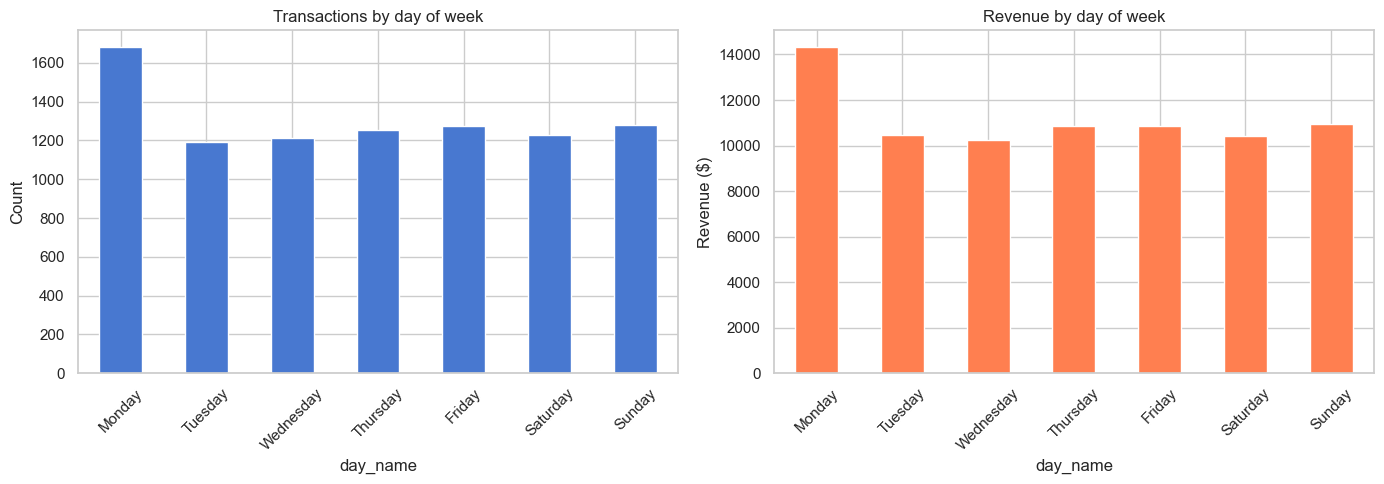

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

day_txn = df.groupby('day_name')['Transaction ID'].count().reindex(day_order)
day_txn.plot(kind='bar', ax=axes[0])
axes[0].set_title('Transactions by day of week')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

day_rev = df.groupby('day_name')['Total Spent'].sum().reindex(day_order)
day_rev.plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Revenue by day of week')
axes[1].set_ylabel('Revenue ($)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('fig_day_of_week.png', bbox_inches='tight')
plt.show()

### 3.4 Weekly revenue over time

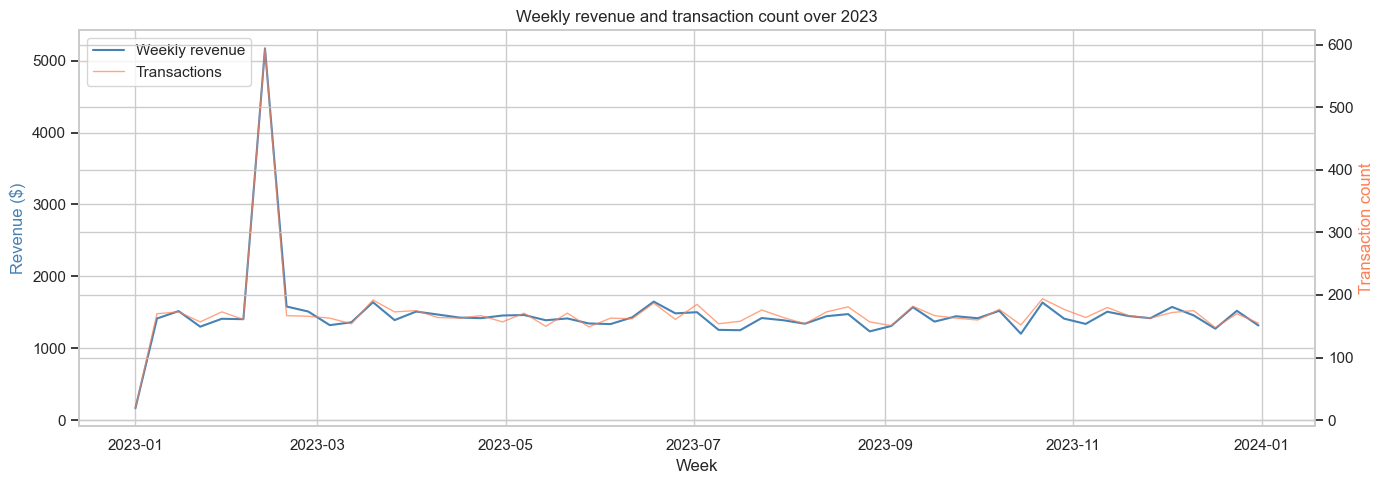

In [23]:
weekly = (
    df.set_index('Transaction Date')
    .resample('W')['Total Spent']
    .agg(['sum', 'count'])
    .rename(columns={'sum': 'revenue', 'count': 'transactions'})
)

fig, ax1 = plt.subplots(figsize=(14, 5))
ax1.plot(weekly.index, weekly['revenue'], color='steelblue', linewidth=1.5, label='Weekly revenue')
ax1.set_ylabel('Revenue ($)', color='steelblue')
ax1.set_xlabel('Week')
ax1.set_title('Weekly revenue and transaction count over 2023')

ax2 = ax1.twinx()
ax2.plot(weekly.index, weekly['transactions'], color='coral', linewidth=1, alpha=0.7, label='Transactions')
ax2.set_ylabel('Transaction count', color='coral')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.savefig('fig_weekly_revenue.png', bbox_inches='tight')
plt.show()

### 3.5 Heatmap: sales by day of week × month

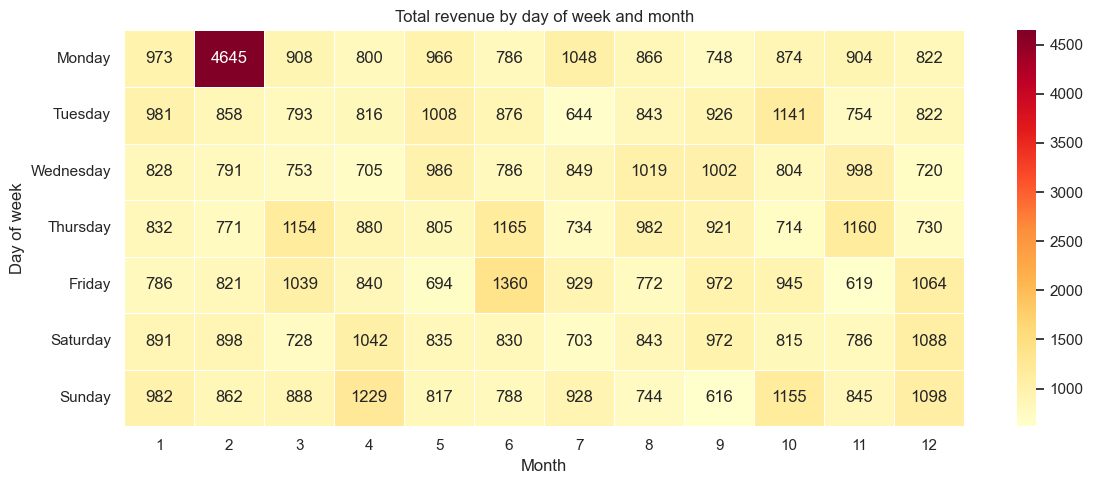

In [24]:
heatmap_data = df.pivot_table(
    values='Total Spent',
    index='day_name',
    columns='month',
    aggfunc='sum'
).reindex(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])

plt.figure(figsize=(12, 5))
sns.heatmap(heatmap_data, annot=True, fmt='.0f', cmap='YlOrRd', linewidths=0.5)
plt.title('Total revenue by day of week and month')
plt.ylabel('Day of week')
plt.xlabel('Month')
plt.tight_layout()
plt.savefig('fig_heatmap_day_month.png', bbox_inches='tight')
plt.show()

### 3.6 Spending distribution: weekday vs weekend, and by season

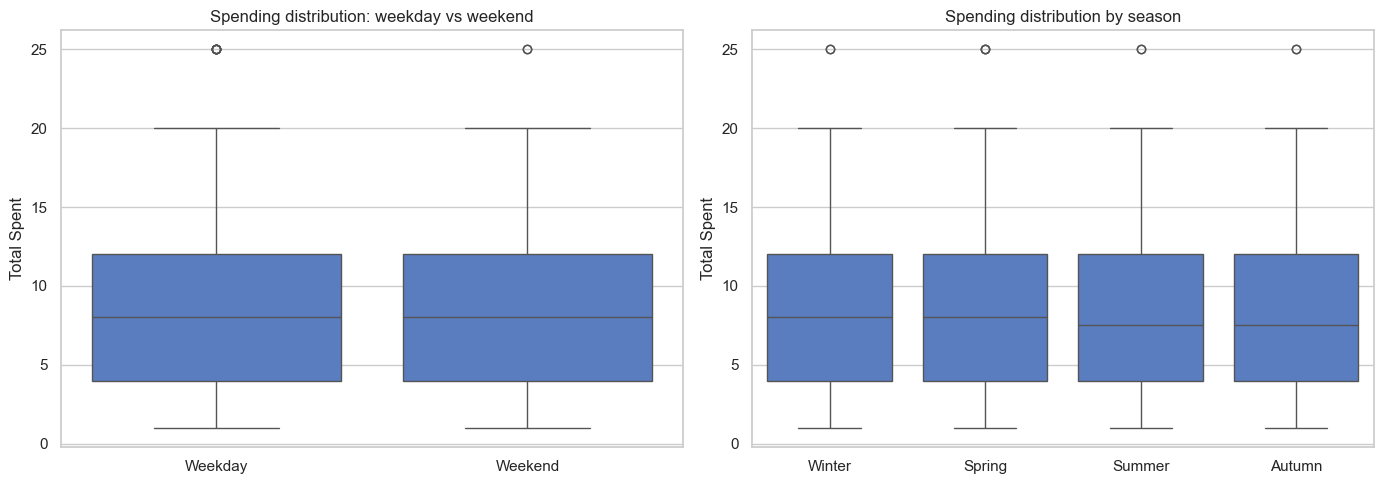

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['weekend_label'] = df['is_weekend'].map({0: 'Weekday', 1: 'Weekend'})
sns.boxplot(data=df, x='weekend_label', y='Total Spent', ax=axes[0])
axes[0].set_title('Spending distribution: weekday vs weekend')
axes[0].set_xlabel('')

sns.boxplot(data=df, x='season', y='Total Spent', ax=axes[1],
            order=['Winter', 'Spring', 'Summer', 'Autumn'])
axes[1].set_title('Spending distribution by season')
axes[1].set_xlabel('')

plt.tight_layout()
plt.savefig('fig_boxplots.png', bbox_inches='tight')
plt.show()

### 3.7 Item sales by season — hot vs cold drinks

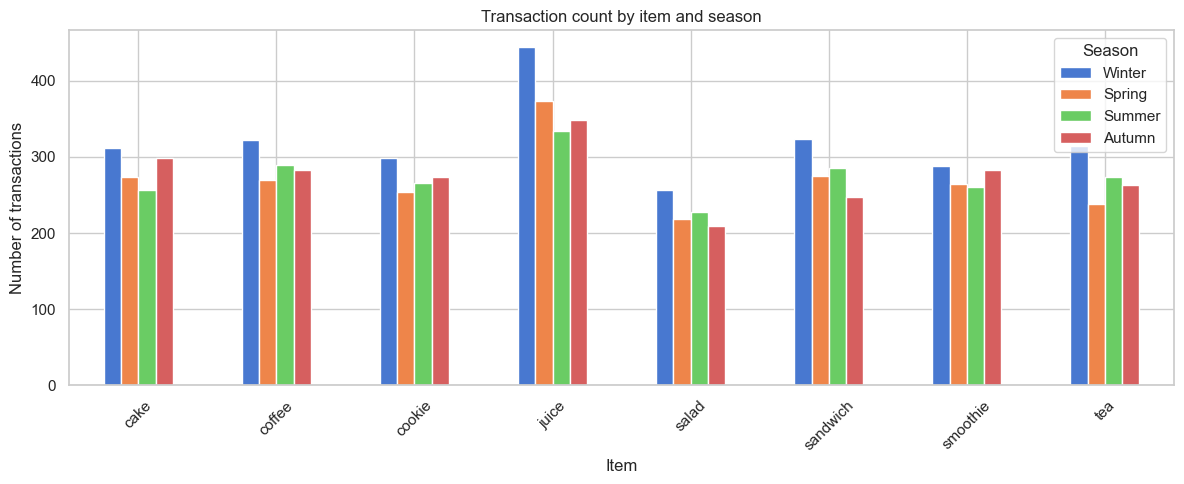

In [26]:
season_item = df.pivot_table(
    values='Transaction ID',
    index='Item',
    columns='season',
    aggfunc='count'
)[['Winter', 'Spring', 'Summer', 'Autumn']]

season_item.plot(kind='bar', figsize=(12, 5))
plt.title('Transaction count by item and season')
plt.ylabel('Number of transactions')
plt.xlabel('Item')
plt.xticks(rotation=45)
plt.legend(title='Season')
plt.tight_layout()
plt.savefig('fig_item_season.png', bbox_inches='tight')
plt.show()

---

# Section 4 — Aggregation and correlation analysis (Person 2)

Aggregate data to the daily level for time series work, then test key hypotheses about what drives sales.

### 4.1 Daily aggregation

In [27]:
daily = (
    df.groupby('Transaction Date')
    .agg(
        total_transactions=('Transaction ID', 'count'),
        total_revenue=('Total Spent', 'sum'),
        avg_quantity=('Quantity', 'mean'),
        unique_items=('Item', 'nunique'),
        is_weekend=('is_weekend', 'first'),
        is_holiday=('is_holiday', 'first'),
        day_of_week=('day_of_week', 'first'),
        month=('month', 'first'),
        season=('season', 'first'),
        days_to_next_holiday=('days_to_next_holiday', 'first'),
        hot_drink_share=('is_hot_drink', 'mean'),
        drinks_share=('item_category', lambda x: (x == 'drinks').mean()),
    )
    .reset_index()
)

print(f'Daily dataset: {len(daily)} days')
daily.head(10)

Daily dataset: 365 days


,Transaction Date,total_transactions,total_revenue,avg_quantity,unique_items,is_weekend,is_holiday,day_of_week,month,season,days_to_next_holiday,hot_drink_share,drinks_share
0,2023-01-01,19,168.0,3.263158,8,1,0,6,1,Winter,1.0,0.368421,0.526316
1,2023-01-02,19,157.5,2.894737,7,0,1,0,1,Winter,0.0,0.210526,0.368421
2,2023-01-03,18,166.0,2.944444,7,0,0,1,1,Winter,48.0,0.055556,0.388889
3,2023-01-04,24,209.5,2.875000,8,0,0,2,1,Winter,47.0,0.291667,0.583333
4,2023-01-05,34,269.5,2.735294,8,0,0,3,1,Winter,46.0,0.235294,0.441176
5,2023-01-06,30,243.0,3.066667,8,0,0,4,1,Winter,45.0,0.433333,0.633333
6,2023-01-07,23,136.5,2.434783,8,1,0,5,1,Winter,44.0,0.086957,0.391304
7,2023-01-08,22,233.5,3.545455,8,1,0,6,1,Winter,43.0,0.181818,0.454545
8,2023-01-09,22,157.0,2.909091,8,0,0,0,1,Winter,42.0,0.454545,0.727273
9,2023-01-10,27,228.5,2.888889,8,0,0,1,1,Winter,41.0,0.259259,0.555556


### 4.2 Daily demand per item (wide format for time series)

In [28]:
daily_demand = df.pivot_table(
    values='Quantity',
    index='Transaction Date',
    columns='Item',
    aggfunc='sum',
    fill_value=0
)

print(f'Daily demand per item: {daily_demand.shape[0]} days × {daily_demand.shape[1]} items')
daily_demand.head(10)

Daily demand per item: 365 days × 8 items


Item,cake,coffee,cookie,juice,salad,sandwich,smoothie,tea
Transaction Date,,,,,,,,
2023-01-01,10.0,16.0,4.0,6.0,5.0,11.0,2.0,8.0
2023-01-02,7.0,3.0,12.0,0.0,4.0,16.0,6.0,7.0
2023-01-03,18.0,3.0,4.0,13.0,3.0,6.0,6.0,0.0
2023-01-04,4.0,12.0,4.0,12.0,4.0,13.0,13.0,7.0
2023-01-05,9.0,14.0,7.0,18.0,11.0,20.0,2.0,12.0
2023-01-06,4.0,23.0,6.0,13.0,9.0,12.0,4.0,21.0
2023-01-07,5.0,1.0,23.0,5.0,4.0,2.0,13.0,3.0
2023-01-08,19.0,10.0,4.0,10.0,8.0,13.0,7.0,7.0
2023-01-09,3.0,22.0,7.0,7.0,5.0,1.0,11.0,8.0


### 4.3 Correlation matrix

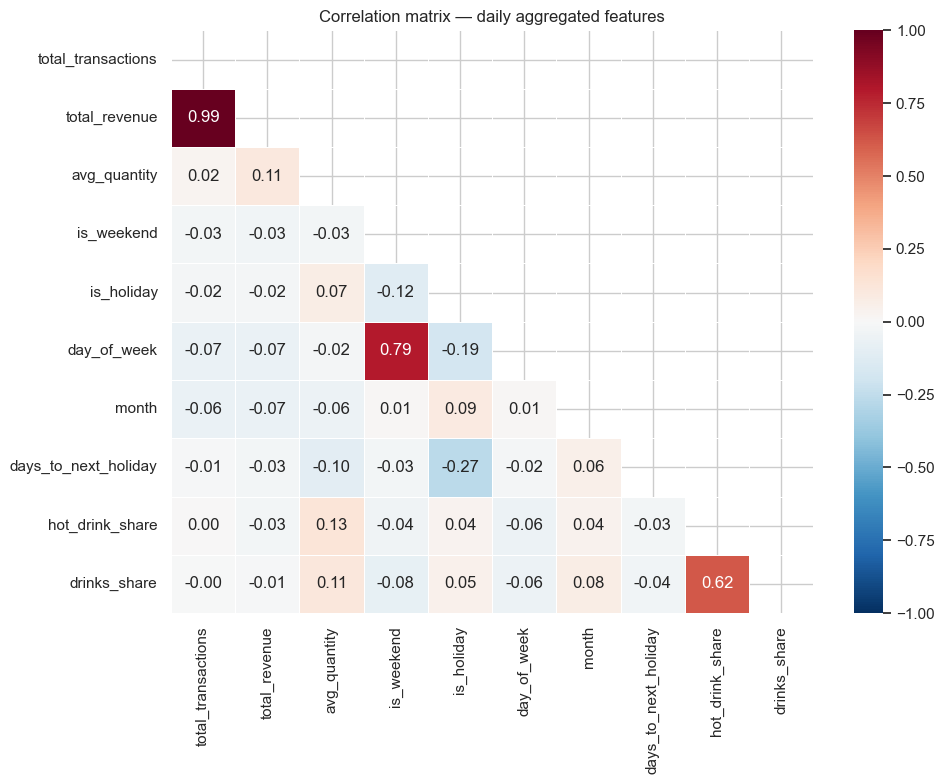

In [29]:
corr_cols = [
    'total_transactions', 'total_revenue', 'avg_quantity',
    'is_weekend', 'is_holiday', 'day_of_week', 'month',
    'days_to_next_holiday', 'hot_drink_share', 'drinks_share'
]
corr_matrix = daily[corr_cols].corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation matrix — daily aggregated features')
plt.tight_layout()
plt.savefig('fig_correlation_matrix.png', bbox_inches='tight')
plt.show()

### 4.4 Hypothesis test: weekend effect on revenue

In [30]:
from scipy import stats

weekday_rev = daily[daily['is_weekend'] == 0]['total_revenue']
weekend_rev = daily[daily['is_weekend'] == 1]['total_revenue']

t_stat, p_value = stats.ttest_ind(weekday_rev, weekend_rev, equal_var=False)

print('Weekend effect on daily revenue:')
print(f'  Weekday mean: ${weekday_rev.mean():.2f}  (n={len(weekday_rev)})')
print(f'  Weekend mean: ${weekend_rev.mean():.2f}  (n={len(weekend_rev)})')
print(f'  t-statistic:  {t_stat:.3f}')
print(f'  p-value:      {p_value:.4f}')
print(f'  Significant at 5%: {"Yes" if p_value < 0.05 else "No"}')

Weekend effect on daily revenue:
  Weekday mean: $218.19  (n=260)
  Weekend mean: $203.63  (n=105)
  t-statistic:  0.924
  p-value:      0.3561
  Significant at 5%: No


### 4.5 Hypothesis test: holiday effect on revenue

In [31]:
holiday_rev = daily[daily['is_holiday'] == 1]['total_revenue']
non_holiday_rev = daily[daily['is_holiday'] == 0]['total_revenue']

t_stat_h, p_value_h = stats.ttest_ind(holiday_rev, non_holiday_rev, equal_var=False)

print('Holiday effect on daily revenue:')
print(f'  Holiday mean:     ${holiday_rev.mean():.2f}  (n={len(holiday_rev)})')
print(f'  Non-holiday mean: ${non_holiday_rev.mean():.2f}  (n={len(non_holiday_rev)})')
print(f'  t-statistic:      {t_stat_h:.3f}')
print(f'  p-value:          {p_value_h:.4f}')
print(f'  Significant at 5%: {"Yes" if p_value_h < 0.05 else "No"}')

Holiday effect on daily revenue:
  Holiday mean:     $194.58  (n=13)
  Non-holiday mean: $214.72  (n=352)
  t-statistic:      -1.139
  p-value:          0.2628
  Significant at 5%: No


### 4.6 Hypothesis test: season × hot drink interaction

Do hot drinks (coffee, tea) sell proportionally more in winter vs summer?

In [32]:
winter_hot = daily[daily['season'] == 'Winter']['hot_drink_share']
summer_hot = daily[daily['season'] == 'Summer']['hot_drink_share']

t_stat_s, p_value_s = stats.ttest_ind(winter_hot, summer_hot, equal_var=False)

print('Season × hot drink interaction (winter vs summer):')
print(f'  Winter hot-drink share: {winter_hot.mean():.3f}  (n={len(winter_hot)} days)')
print(f'  Summer hot-drink share: {summer_hot.mean():.3f}  (n={len(summer_hot)} days)')
print(f'  t-statistic:            {t_stat_s:.3f}')
print(f'  p-value:                {p_value_s:.4f}')
print(f'  Significant at 5%: {"Yes" if p_value_s < 0.05 else "No"}')

Season × hot drink interaction (winter vs summer):
  Winter hot-drink share: 0.247  (n=90 days)
  Summer hot-drink share: 0.259  (n=92 days)
  t-statistic:            -0.858
  p-value:                0.3920
  Significant at 5%: No


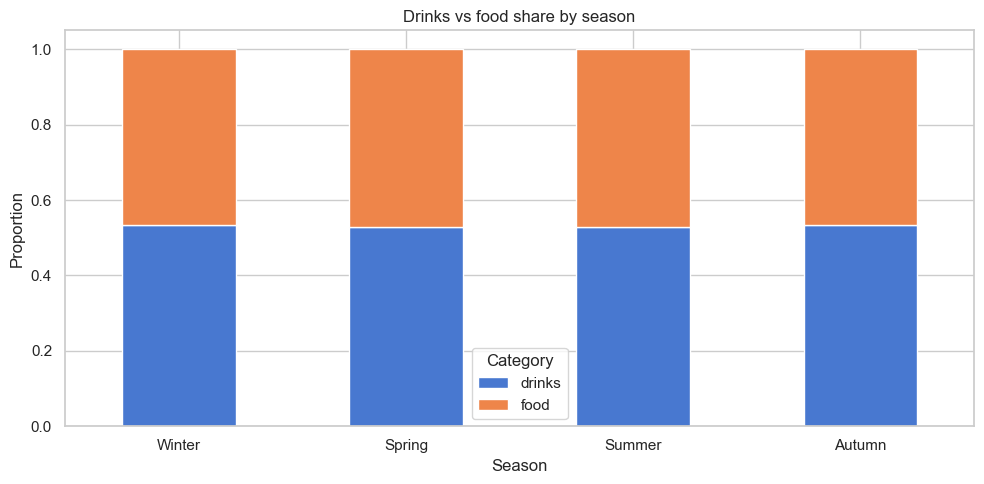

In [33]:
season_drink = df.groupby(['season', 'item_category'])['Transaction ID'].count().unstack()
season_drink_pct = season_drink.div(season_drink.sum(axis=1), axis=0)

season_drink_pct.reindex(['Winter', 'Spring', 'Summer', 'Autumn']).plot(
    kind='bar', stacked=True, figsize=(10, 5)
)
plt.title('Drinks vs food share by season')
plt.ylabel('Proportion')
plt.xlabel('Season')
plt.xticks(rotation=0)
plt.legend(title='Category')
plt.tight_layout()
plt.savefig('fig_season_drink_food.png', bbox_inches='tight')
plt.show()

### 4.7 Key correlations summary

In [34]:
target = 'total_revenue'
correlations = corr_matrix[target].drop(target).sort_values(key=abs, ascending=False)
print(f'Features most correlated with daily {target}:')
for feat, corr in correlations.items():
    print(f'  {feat:30s}  r = {corr:+.3f}')

Features most correlated with daily total_revenue:
  total_transactions              r = +0.992
  avg_quantity                    r = +0.109
  month                           r = -0.069
  day_of_week                     r = -0.068
  is_weekend                      r = -0.032
  days_to_next_holiday            r = -0.025
  hot_drink_share                 r = -0.025
  is_holiday                      r = -0.018
  drinks_share                    r = -0.008


---

# Section 5 — Time series forecasting (Person 3)

**Objective:** Build demand forecasting models for the cafe using weekly aggregated data.

**Suggested approach:**
1. Use the `daily` and `daily_demand` dataframes from Section 4
2. Aggregate to weekly level for smoother time series
3. Perform seasonal decomposition (trend, seasonality, residual)
4. Fit ARIMA or dynamic regression (with is_holiday, is_weekend as exogenous variables)
5. Train/test split: first 10 months train, last 2 months test
6. Evaluate with RMSE and MAE

**Useful libraries:** `statsmodels` (ARIMA, seasonal_decompose), `sklearn` (metrics)

```python
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, mean_absolute_error
```

In [35]:
# TODO (Person 3): implement time series forecasting here

---

# Section 6 — Regression models (Person 3)

**Objective:** Predict daily revenue using the engineered features.

**Suggested approach:**
1. Use the `daily` dataframe from Section 4 as the modelling dataset
2. Target variable: `total_revenue`
3. Features: `day_of_week`, `is_weekend`, `month`, `is_holiday`, `days_to_next_holiday`, `hot_drink_share`, `drinks_share`
4. Encode season as dummies
5. Compare OLS regression vs Ridge/Lasso (regularised)
6. Report R², adjusted R², coefficient interpretation
7. Check for autocorrelation in residuals (Durbin–Watson) — if present, consider dynamic regression

**Useful libraries:** `statsmodels` (OLS), `sklearn` (Ridge, Lasso, cross-validation)

```python
import statsmodels.api as sm
from sklearn.linear_model import Ridge, Lasso
from sklearn.model_selection import cross_val_score
```

In [36]:
# TODO (Person 3): implement regression models here

---

# Section 7 — Optimisation (Person 4)

**Objective:** Formulate and solve an inventory optimisation problem for the cafe.

**Problem framing:**
- The cafe must decide each day how many units of each item to prepare
- Over-preparing leads to waste (perishable items); under-preparing leads to lost sales
- Use demand forecasts from Section 5 as inputs

**Suggested formulation (LP/IP using gurobipy):**

**Sets:**
- $i \in I$ — items (coffee, tea, juice, smoothie, cake, cookie, sandwich, salad)

**Parameters:**
- $p_i$ — selling price per unit (from data)
- $c_i$ — cost per unit (assumed — suggest reasonable values)
- $w_i$ — waste cost per unsold unit
- $d_i$ — forecasted daily demand (from Section 5)
- $B$ — daily preparation budget
- $K$ — total preparation capacity (units per day)

**Decision variables:**
- $q_i$ — quantity of item $i$ to prepare (integer)

**Objective:** maximise expected profit
$$\max \sum_{i \in I} \left[ p_i \cdot \min(q_i, d_i) - c_i \cdot q_i - w_i \cdot \max(q_i - d_i, 0) \right]$$

**Constraints:**
- Budget: $\sum_i c_i \cdot q_i \le B$
- Capacity: $\sum_i q_i \le K$
- Minimum service: $q_i \ge \alpha \cdot d_i$ for some service level $\alpha$
- Non-negativity, integrality

Solve separately for weekday vs weekend scenarios, and for different seasons.

**Useful libraries:** `gurobipy`

```python
import gurobipy as gp
from gurobipy import GRB
```

In [37]:
# TODO (Person 4): implement optimisation model here

---

# Section 8 — Results summary and sensitivity analysis (Person 5)

**Objective:** Synthesise findings from all sections and perform sensitivity analysis on the optimisation.

**Suggested content:**
1. Compile a results summary table: key metrics from each section
2. Sensitivity analysis on optimisation:
   - Vary the daily budget $B$ and observe how profit changes
   - Vary demand uncertainty (±10%, ±20%) and check robustness
   - Vary the service level $\alpha$
3. Business insights: what actionable recommendations can the cafe owner take?
4. Prepare polished figures and tables for the report appendices

In [38]:
# TODO (Person 5): implement results summary and sensitivity analysis here